# Phase 3 — Model Development (Classification Systems)

## Hospital Visit Risk Classification

**Business Purpose:** Predict whether a hospital visit represents a **Low**, **Medium**, or **High** operational and clinical risk.

**Target Variable:** `risk_score` (Low | Medium | High)

**Approach:**
1. Correlation-driven feature selection
2. Time-based train/test split (earliest 80% train, latest 20% test)
3. Baseline model — Logistic Regression
4. Advanced model — XGBoost
5. Hyperparameter tuning via GridSearchCV
6. Comprehensive evaluation — Accuracy, F1, Confusion Matrix, ROC-AUC (OvR)

## Step 1 — Setup & Configuration

In [27]:
# ============================================================
# All Imports & Reproducibility Configuration
# ============================================================

import random
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ============================================================
# Reproducibility — Single source of truth for all random seeds
# ============================================================
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

warnings.filterwarnings("ignore")

# Plot defaults
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("All imports loaded. RANDOM_STATE =", RANDOM_STATE)

All imports loaded. RANDOM_STATE = 42


In [28]:
# ============================================================
# Load Data
# ============================================================

DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])

print(f"Dataset shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (25000, 33)

Column dtypes:
patient_id                             int64
age                                    int64
gender                                object
city                                  object
insurance_provider                    object
chronic_flag                           int64
registration_date             datetime64[ns]
visit_id                               int64
visit_date                    datetime64[ns]
department                            object
visit_type                            object
length_of_stay_hours                 float64
risk_score                            object
doctor_id                              int64
bill_id                                int64
billed_amount                        float64
approved_amount                      float64
claim_status                          object
payment_days                         float64
billing_date                  datetime64[ns]
visit_frequency                        int64
avg_length_o

,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,...,total_billed,avg_payment_days,provider_rejection_rate,doctor_rejection_rate,visit_month,visit_day_of_week,visit_quarter,is_weekend,days_between_reg_and_visit,billing_delay_days
0,2964,25,F,Chennai,HealthPlus,1,2025-07-04,3,2025-07-13,ICU,...,44010.80,4.250000,0.149678,0.193916,7,6,3,1,9,-174
1,4271,42,F,Mumbai,MediCareX,1,2025-10-31,669,2026-01-17,Neurology,...,180737.86,15.222222,0.152480,0.168033,1,5,1,1,78,-362
2,1826,52,M,Pune,CareOne,1,2025-01-23,1264,2025-10-01,General,...,116149.24,9.500000,0.148655,0.145594,10,2,4,0,251,-254
3,1224,52,M,Delhi,CareOne,1,2025-06-23,1326,2025-11-05,General,...,93356.58,10.000000,0.148655,0.153226,11,2,4,0,135,-289
4,1318,39,M,Chennai,HealthPlus,1,2025-11-13,1455,2025-08-20,Cardiology,...,77804.09,20.600000,0.149678,0.114068,8,2,3,0,-85,-212


In [29]:
# Target variable distribution
print("Target Variable — risk_score Distribution:")
print(df["risk_score"].value_counts())
print(f"\nPercentages:")
print(df["risk_score"].value_counts(normalize=True).round(4) * 100)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nDescriptive statistics:")
df.describe()

Target Variable — risk_score Distribution:
risk_score
Low       12470
Medium     7496
High       5034
Name: count, dtype: int64

Percentages:
risk_score
Low       49.88
Medium    29.98
High      20.14
Name: proportion, dtype: float64

Missing values: 0

Descriptive statistics:


,patient_id,age,chronic_flag,registration_date,visit_id,visit_date,length_of_stay_hours,doctor_id,bill_id,billed_amount,...,total_billed,avg_payment_days,provider_rejection_rate,doctor_rejection_rate,visit_month,visit_day_of_week,visit_quarter,is_weekend,days_between_reg_and_visit,billing_delay_days
count,25000.00000,25000.000000,25000.000000,25000,25000.000000,25000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.0000,25000.000000,25000.000000,25000.000000,25000.000000
mean,2509.51536,44.768320,0.502600,2025-07-18 16:17:11.039999744,12500.500000,2025-07-21 15:25:51.744000,19.551584,150.172400,12500.500000,20870.757442,...,124538.751034,13.036320,0.151880,0.151880,6.520360,3.0000,2.508080,0.285200,2.964360,1.153320
min,1.00000,1.000000,0.000000,2025-01-20 00:00:00,1.000000,2025-01-20 00:00:00,0.500000,100.000000,1.000000,500.000000,...,500.000000,1.000000,0.148655,0.106122,1.000000,0.0000,1.000000,0.000000,-364.000000,-362.000000
25%,1249.00000,33.000000,0.000000,2025-04-16 00:00:00,6250.750000,2025-04-21 00:00:00,9.960000,125.000000,6250.750000,11582.450000,...,84533.490000,10.888889,0.148655,0.136882,4.000000,1.0000,2.000000,0.000000,-101.000000,-106.000000
50%,2505.00000,45.000000,1.000000,2025-07-19 00:00:00,12500.500000,2025-07-21 00:00:00,18.205000,151.000000,12500.500000,19644.850000,...,119562.600000,12.845238,0.149678,0.151261,7.000000,3.0000,3.000000,0.000000,4.000000,1.000000
75%,3764.00000,57.000000,1.000000,2025-10-19 00:00:00,18750.250000,2025-10-21 00:00:00,27.312500,175.000000,18750.250000,28398.065000,...,158161.700000,15.000000,0.152480,0.163265,10.000000,5.0000,4.000000,1.000000,109.000000,109.000000
max,5000.00000,90.000000,1.000000,2026-01-20 00:00:00,25000.000000,2026-01-20 00:00:00,78.420000,200.000000,25000.000000,88539.010000,...,356672.540000,53.000000,0.156915,0.227106,12.000000,6.0000,4.000000,1.000000,364.000000,364.000000
std,1448.68904,17.784232,0.500003,NaN,7217.022701,NaN,12.314004,29.135796,7217.022701,12606.285782,...,55549.314864,3.324006,0.003157,0.022024,3.457534,2.0012,1.116273,0.451519,148.684726,149.519309


## Step 2 — Feature Analysis & Selection

Drop ID columns, raw date columns, and `billing_delay_days` (unreliable due to frozen `billing_date` values). Temporarily encode categoricals to compute correlations, then use the heatmap to identify the most relevant features for predicting `risk_score`.

In [30]:
# ============================================================
# Prepare data for correlation analysis
# ============================================================

# Columns to exclude from modelling entirely
DROP_COLS = [
    "patient_id", "visit_id", "bill_id", "doctor_id",   # IDs — no predictive value
    "visit_date", "registration_date", "billing_date",    # Raw dates — temporal features already extracted
    "billing_delay_days",                                  # Data quality issue — billing_date is mostly frozen
]

df_corr = df.drop(columns=DROP_COLS).copy()

# Encode risk_score as ordinal for correlation: Low=0, Medium=1, High=2
risk_order = {"Low": 0, "Medium": 1, "High": 2}
df_corr["risk_score"] = df_corr["risk_score"].map(risk_order)

# Label-encode remaining categorical columns for correlation analysis only
cat_cols = df_corr.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

le_temp = {}
for col in cat_cols:
    le_temp[col] = LabelEncoder()
    df_corr[col] = le_temp[col].fit_transform(df_corr[col])

print(f"\nCorrelation matrix shape: {df_corr.shape}")
df_corr.head()

Categorical columns to encode: ['gender', 'city', 'insurance_provider', 'department', 'visit_type', 'claim_status']

Correlation matrix shape: (25000, 25)


,age,gender,city,insurance_provider,chronic_flag,department,visit_type,length_of_stay_hours,risk_score,billed_amount,...,days_since_registration,total_billed,avg_payment_days,provider_rejection_rate,doctor_rejection_rate,visit_month,visit_day_of_week,visit_quarter,is_weekend,days_between_reg_and_visit
0,25,0,1,1,1,3,0,34.36,0,5038.97,...,200,44010.80,4.250000,0.149678,0.193916,7,6,3,1,9
1,42,0,4,2,1,4,1,12.74,1,21706.39,...,81,180737.86,15.222222,0.152480,0.168033,1,5,1,1,78
2,52,1,5,0,1,2,1,24.16,0,25918.41,...,362,116149.24,9.500000,0.148655,0.145594,10,2,4,0,251
3,52,1,2,0,1,2,2,7.43,0,21173.56,...,211,93356.58,10.000000,0.148655,0.153226,11,2,4,0,135
4,39,1,1,1,1,0,0,17.72,2,8649.89,...,68,77804.09,20.600000,0.149678,0.114068,8,2,3,0,-85


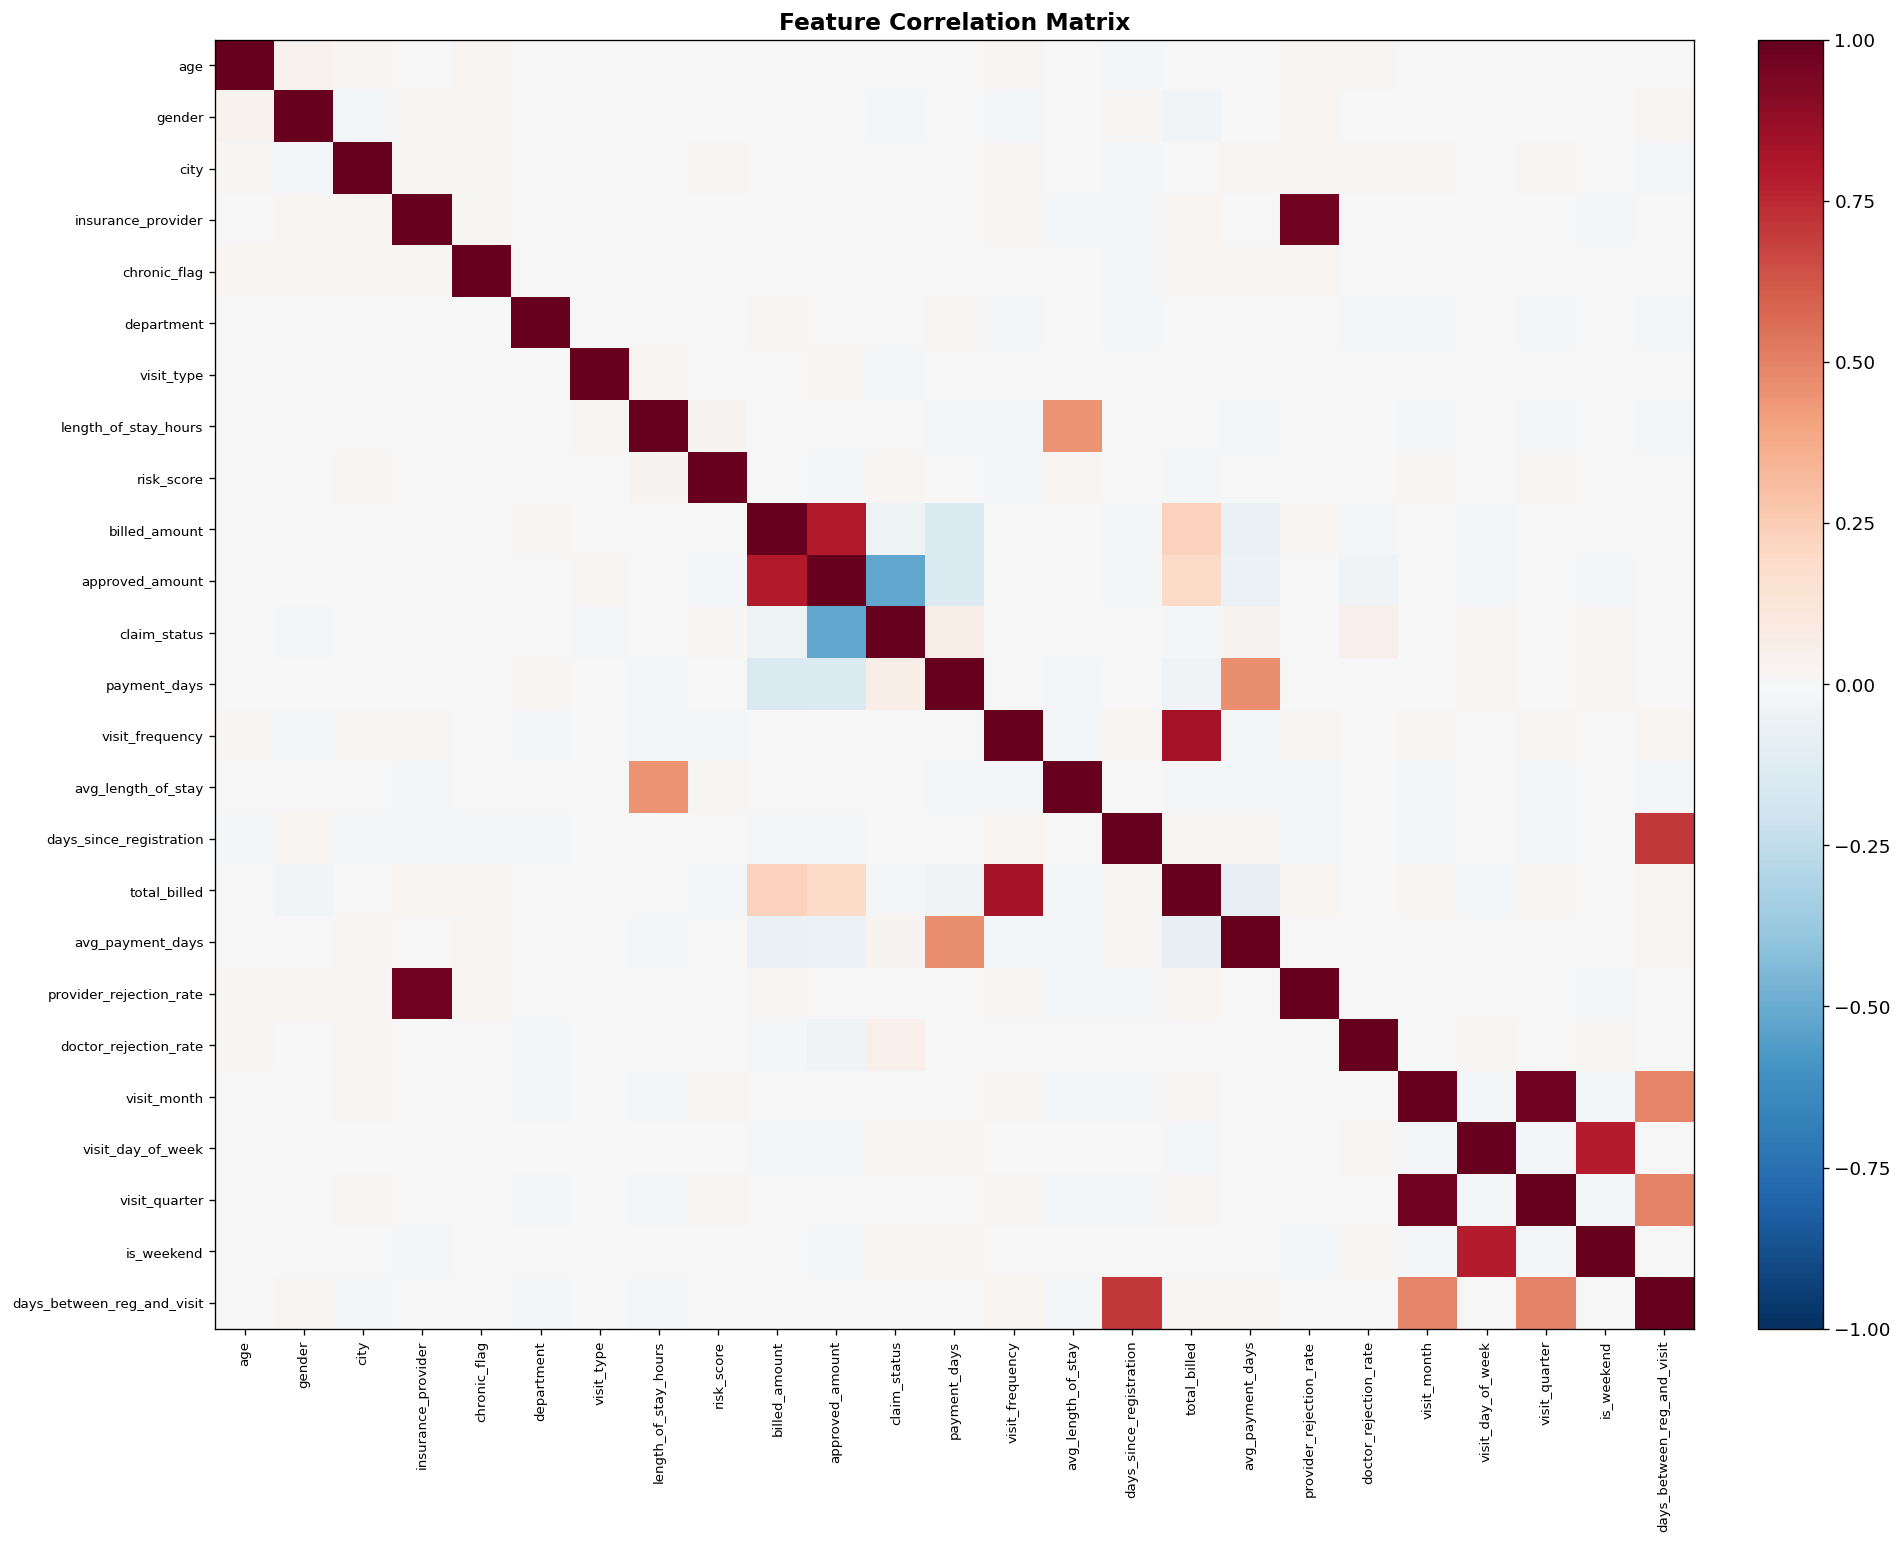

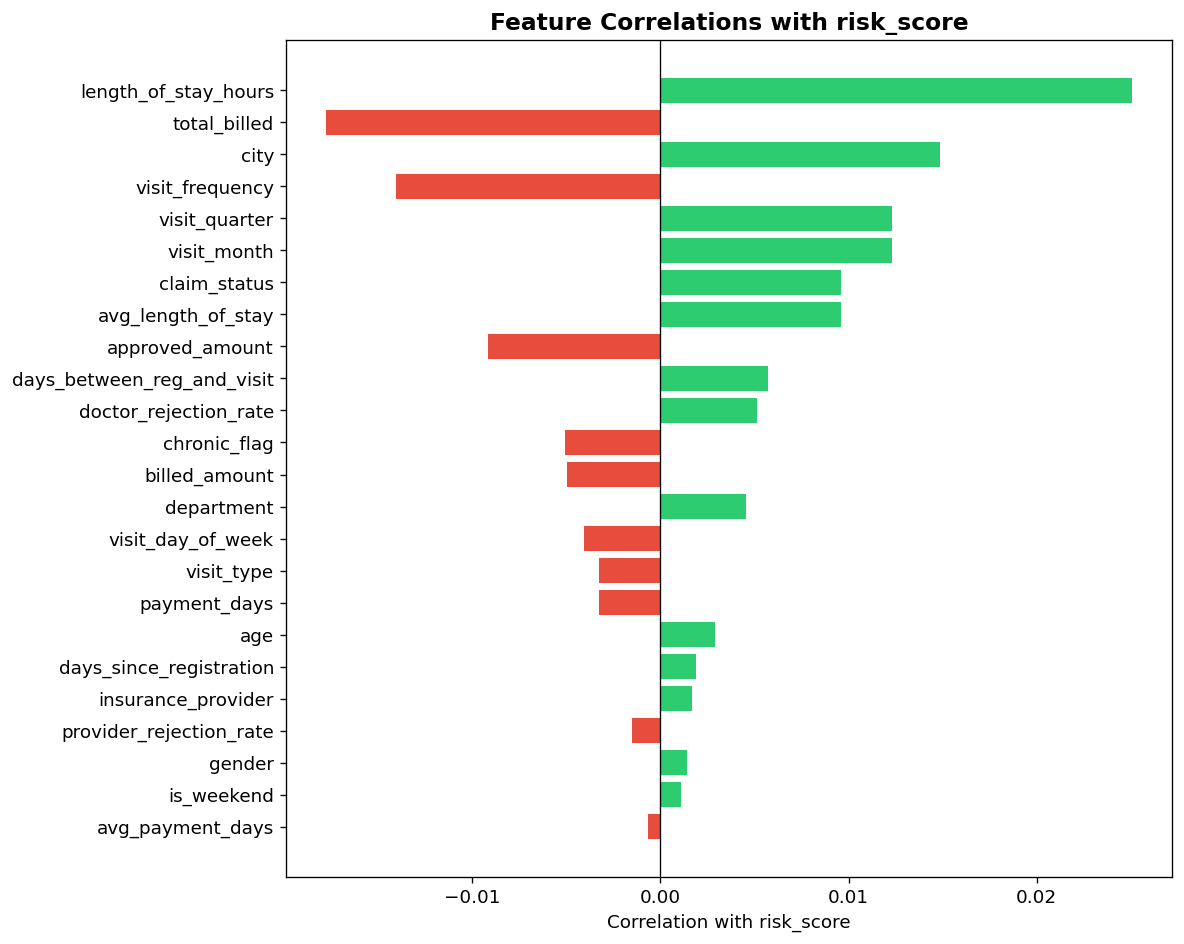

Correlations with risk_score (sorted by |correlation|):
length_of_stay_hours          0.0251
total_billed                 -0.0178
city                          0.0148
visit_frequency              -0.0141
visit_quarter                 0.0123
visit_month                   0.0123
claim_status                  0.0096
avg_length_of_stay            0.0096
approved_amount              -0.0092
days_between_reg_and_visit    0.0057
doctor_rejection_rate         0.0052
chronic_flag                 -0.0051
billed_amount                -0.0050
department                    0.0046
visit_day_of_week            -0.0040
visit_type                   -0.0033
payment_days                 -0.0032
age                           0.0029
days_since_registration       0.0019
insurance_provider            0.0017
provider_rejection_rate      -0.0015
gender                        0.0014
is_weekend                    0.0011
avg_payment_days             -0.0006
Name: risk_score, dtype: float64


In [31]:
# ============================================================
# Correlation Heatmap
# ============================================================

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Tick labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Correlation with target — sorted by absolute value
risk_corr = corr_matrix["risk_score"].drop("risk_score").sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in risk_corr.values]
ax.barh(risk_corr.index, risk_corr.values, color=colors)
ax.set_xlabel("Correlation with risk_score")
ax.set_title("Feature Correlations with risk_score", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Correlations with risk_score (sorted by |correlation|):")
print(risk_corr.sort_values(key=abs, ascending=False).round(4))

In [32]:
# ============================================================
# Feature Selection — based on correlation analysis
# ============================================================
# NOTE: All correlations are weak (max |r| = 0.025). This is expected when
# the target is categorical — Pearson correlation measures linear relationships
# and does not capture non-linear patterns. Tree-based models (XGBoost) can
# still extract predictive signal from these features.
#
# Strategy: Include all features with |r| >= 0.005 to retain business-relevant
# features. Let the models determine what's useful.

CORRELATION_THRESHOLD = 0.005

risk_corr_abs = corr_matrix["risk_score"].drop("risk_score").abs().sort_values(ascending=False)
selected_features = risk_corr_abs[risk_corr_abs >= CORRELATION_THRESHOLD].index.tolist()
dropped_features = risk_corr_abs[risk_corr_abs < CORRELATION_THRESHOLD].index.tolist()

print(f"Correlation threshold: |r| >= {CORRELATION_THRESHOLD}")
print(f"\nSelected features ({len(selected_features)}):")
for f in selected_features:
    print(f"  {f:30s} | r = {corr_matrix['risk_score'][f]:+.4f}")

if dropped_features:
    print(f"\nDropped features ({len(dropped_features)}) — near-zero correlation:")
    for f in dropped_features:
        print(f"  {f:30s} | r = {corr_matrix['risk_score'][f]:+.4f}")

Correlation threshold: |r| >= 0.005

Selected features (12):
  length_of_stay_hours           | r = +0.0251
  total_billed                   | r = -0.0178
  city                           | r = +0.0148
  visit_frequency                | r = -0.0141
  visit_quarter                  | r = +0.0123
  visit_month                    | r = +0.0123
  claim_status                   | r = +0.0096
  avg_length_of_stay             | r = +0.0096
  approved_amount                | r = -0.0092
  days_between_reg_and_visit     | r = +0.0057
  doctor_rejection_rate          | r = +0.0052
  chronic_flag                   | r = -0.0051

Dropped features (12) — near-zero correlation:
  billed_amount                  | r = -0.0050
  department                     | r = +0.0046
  visit_day_of_week              | r = -0.0040
  visit_type                     | r = -0.0033
  payment_days                   | r = -0.0032
  age                            | r = +0.0029
  days_since_registration        | r = +0.001

## Step 3 — Data Preparation

1. **Time-based train/test split** — Sort by `visit_date`, 80th percentile date as cutoff
2. **Encoding** — One-Hot for low-cardinality categoricals, LabelEncoder for target
3. **Scaling** — StandardScaler on all numeric features (fit on train only)
4. **SMOTE** — Oversample minority classes on training data only

In [33]:
# ============================================================
# Time-Based Train/Test Split
# ============================================================

# Sort by visit_date to ensure chronological order
df_sorted = df.sort_values("visit_date").reset_index(drop=True)

# 80th percentile date as cutoff
split_idx = int(len(df_sorted) * 0.80)
split_date = df_sorted.iloc[split_idx]["visit_date"]

train_df = df_sorted[df_sorted["visit_date"] < split_date].copy()
test_df = df_sorted[df_sorted["visit_date"] >= split_date].copy()

print(f"Split date: {split_date.date()}")
print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/len(df_sorted)*100:.1f}%) | {train_df['visit_date'].min().date()} to {train_df['visit_date'].max().date()}")
print(f"Test:  {test_df.shape[0]} rows ({test_df.shape[0]/len(df_sorted)*100:.1f}%) | {test_df['visit_date'].min().date()} to {test_df['visit_date'].max().date()}")

print(f"\nTrain class distribution:")
print(train_df["risk_score"].value_counts())
print(f"\nTest class distribution:")
print(test_df["risk_score"].value_counts())

Split date: 2025-11-08
Train: 19947 rows (79.8%) | 2025-01-20 to 2025-11-07
Test:  5053 rows (20.2%) | 2025-11-08 to 2026-01-20

Train class distribution:
risk_score
Low       9963
Medium    5984
High      4000
Name: count, dtype: int64

Test class distribution:
risk_score
Low       2507
Medium    1512
High      1034
Name: count, dtype: int64


In [34]:
# ============================================================
# Separate Features and Target, Encode & Scale
# ============================================================

# Identify which selected features are categorical vs numeric
cat_features = [f for f in selected_features if df[f].dtype == "object"]
num_features = [f for f in selected_features if df[f].dtype != "object"]

print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Numeric features ({len(num_features)}): {num_features}")

# --- Encode target variable ---
target_encoder = LabelEncoder()
target_encoder.fit(["Low", "Medium", "High"])  # Fixed order: High=0, Low=1, Medium=2

y_train = target_encoder.transform(train_df["risk_score"])
y_test = target_encoder.transform(test_df["risk_score"])

print(f"\nTarget encoding: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

# --- One-Hot encode categorical features ---
train_features = train_df[selected_features].copy()
test_features = test_df[selected_features].copy()

train_encoded = pd.get_dummies(train_features, columns=cat_features, drop_first=True)
test_encoded = pd.get_dummies(test_features, columns=cat_features, drop_first=True)

# Align columns — ensure test has same columns as train (handle unseen categories)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

print(f"\nEncoded feature matrix shape — Train: {train_encoded.shape}, Test: {test_encoded.shape}")

# --- Scale numeric features ---
scaler = StandardScaler()
scaler.fit(train_encoded[num_features])  # Fit on train only

train_encoded[num_features] = scaler.transform(train_encoded[num_features])
test_encoded[num_features] = scaler.transform(test_encoded[num_features])

X_train = train_encoded.values
X_test = test_encoded.values

feature_names = train_encoded.columns.tolist()
print(f"Final feature count: {len(feature_names)}")

Categorical features (2): ['city', 'claim_status']
Numeric features (10): ['length_of_stay_hours', 'total_billed', 'visit_frequency', 'visit_quarter', 'visit_month', 'avg_length_of_stay', 'approved_amount', 'days_between_reg_and_visit', 'doctor_rejection_rate', 'chronic_flag']

Target encoding: {np.str_('High'): np.int64(0), np.str_('Low'): np.int64(1), np.str_('Medium'): np.int64(2)}

Encoded feature matrix shape — Train: (19947, 17), Test: (5053, 17)
Final feature count: 17


In [35]:
# ============================================================
# SMOTE — Handle Class Imbalance (Training Data Only)
# ============================================================

print("Before SMOTE — Training class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = target_encoder.inverse_transform([u])[0]
    print(f"  {label}: {c} ({c/len(y_train)*100:.1f}%)")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — Training class distribution:")
unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    label = target_encoder.inverse_transform([u])[0]
    print(f"  {label}: {c} ({c/len(y_train_sm)*100:.1f}%)")

print(f"\nTraining set: {X_train.shape} → {X_train_sm.shape}")
print(f"Test set (unchanged): {X_test.shape}")

Before SMOTE — Training class distribution:
  High: 4000 (20.1%)
  Low: 9963 (49.9%)
  Medium: 5984 (30.0%)

After SMOTE — Training class distribution:
  High: 9963 (33.3%)
  Low: 9963 (33.3%)
  Medium: 9963 (33.3%)

Training set: (19947, 17) → (29889, 17)
Test set (unchanged): (5053, 17)


In [36]:
# ============================================================
# Evaluation Helper — reused across all models
# ============================================================

def evaluate_model(model, X_test, y_test, model_name, target_encoder):
    """Evaluate a model and return metrics dict. Plots confusion matrix and ROC curves."""

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

    class_names = target_encoder.classes_

    # --- Classification Report ---
    print(f"{'='*60}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*60}")
    print(f"\nAccuracy:     {acc:.4f}")
    print(f"Macro F1:     {f1_macro:.4f}")
    print(f"Weighted F1:  {f1_weighted:.4f}")
    print(f"ROC-AUC (OvR): {roc_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{model_name} — Confusion Matrix")

    # Annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=12)

    # --- ROC Curves (One-vs-Rest) ---
    ax = axes[1]
    colors = ["#e74c3c", "#3498db", "#2ecc71"]
    for idx, class_name in enumerate(class_names):
        y_binary = (y_test == idx).astype(int)
        fpr, tpr, _ = roc_curve(y_binary, y_proba[:, idx])
        class_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[idx], linewidth=2, label=f"{class_name} (AUC = {class_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name} — ROC Curves (OvR)")
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1_macro, 4),
        "Weighted F1": round(f1_weighted, 4),
        "ROC-AUC (OvR)": round(roc_auc, 4),
    }

# Store results for comparison
results = []
print("Evaluation helper ready.")

Evaluation helper ready.


## Step 4 — Baseline Model: Logistic Regression

Multinomial Logistic Regression with `class_weight="balanced"` as a simple, interpretable baseline. This gives us a performance floor to compare the advanced model against.

  Logistic Regression — Evaluation Results

Accuracy:     0.3196
Macro F1:     0.3081
Weighted F1:  0.3227
ROC-AUC (OvR): 0.5063

Classification Report:
              precision    recall  f1-score   support

        High       0.20      0.26      0.23      1034
         Low       0.51      0.26      0.34      2507
      Medium       0.29      0.46      0.36      1512

    accuracy                           0.32      5053
   macro avg       0.33      0.33      0.31      5053
weighted avg       0.38      0.32      0.32      5053



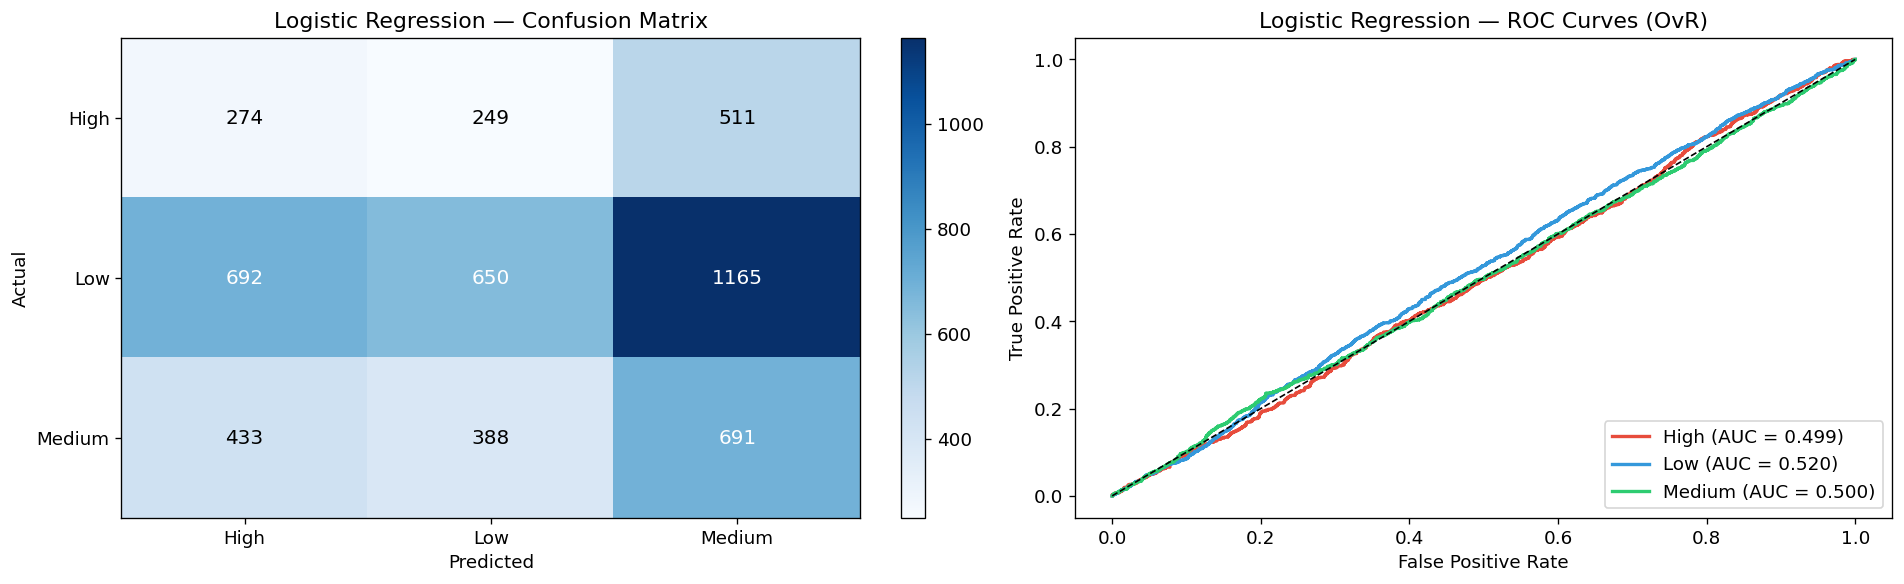

In [37]:
# ============================================================
# Train Logistic Regression
# ============================================================

lr_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
)
lr_model.fit(X_train_sm, y_train_sm)

lr_results = evaluate_model(lr_model, X_test, y_test, "Logistic Regression", target_encoder)
results.append(lr_results)

## Step 5 — Advanced Model: XGBoost

Gradient-boosted tree ensemble — typically outperforms linear models on tabular data. First trained with reasonable defaults, then tuned via GridSearchCV in the next phase.

  XGBoost (Default) — Evaluation Results

Accuracy:     0.4445
Macro F1:     0.3083
Weighted F1:  0.3886
ROC-AUC (OvR): 0.5114

Classification Report:
              precision    recall  f1-score   support

        High       0.20      0.03      0.05      1034
         Low       0.50      0.73      0.59      2507
      Medium       0.31      0.26      0.28      1512

    accuracy                           0.44      5053
   macro avg       0.34      0.34      0.31      5053
weighted avg       0.38      0.44      0.39      5053



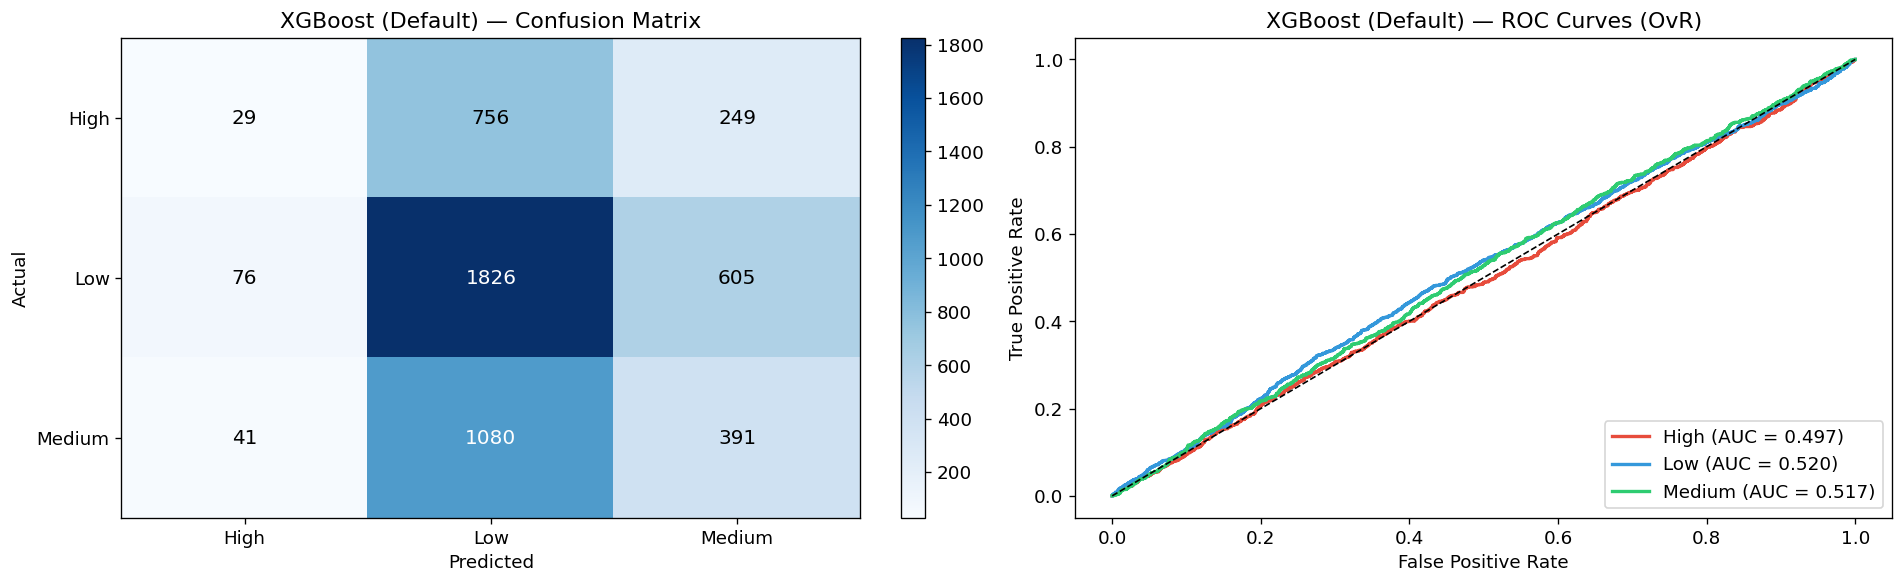

In [38]:
# ============================================================
# Train XGBoost (Default Hyperparameters)
# ============================================================

xgb_model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    use_label_encoder=False,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
)
xgb_model.fit(X_train_sm, y_train_sm)

xgb_results = evaluate_model(xgb_model, X_test, y_test, "XGBoost (Default)", target_encoder)
results.append(xgb_results)

## Step 5b — Advanced Model: Random Forest

Bagging-based ensemble — compared against XGBoost to see if a different ensemble strategy captures the signal better.

  Random Forest — Evaluation Results

Accuracy:     0.4302
Macro F1:     0.3205
Weighted F1:  0.3928
ROC-AUC (OvR): 0.5086

Classification Report:
              precision    recall  f1-score   support

        High       0.19      0.07      0.10      1034
         Low       0.51      0.68      0.58      2507
      Medium       0.30      0.26      0.28      1512

    accuracy                           0.43      5053
   macro avg       0.33      0.34      0.32      5053
weighted avg       0.38      0.43      0.39      5053



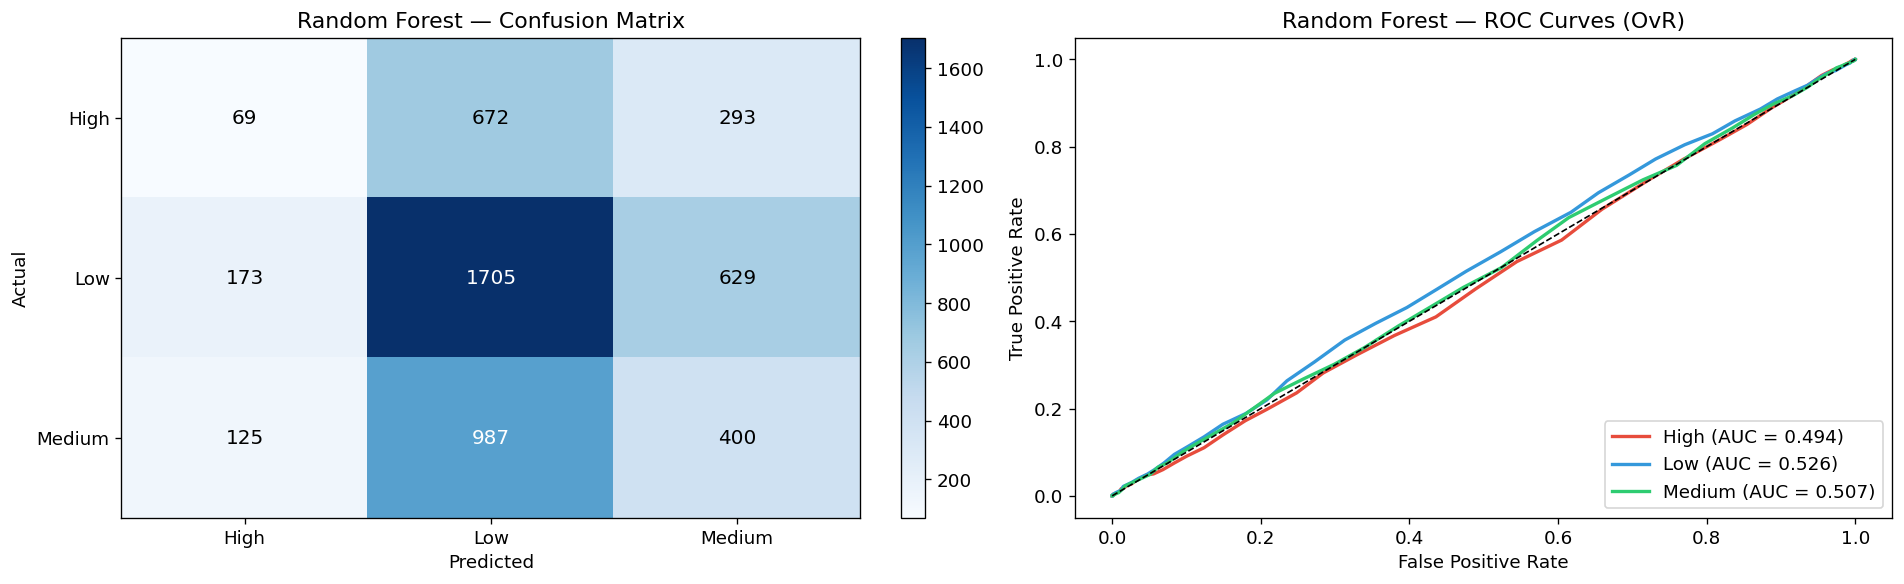

In [39]:
# ============================================================
# Train Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=None,
    class_weight="balanced",
    n_jobs=-1,
)
rf_model.fit(X_train_sm, y_train_sm)

rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest", target_encoder)
results.append(rf_results)

## Step 6 — Hyperparameter Tuning (GridSearchCV)

Systematic search over a grid of XGBoost hyperparameters using 3-fold cross-validation with macro F1-score as the optimization metric (treats all risk classes equally).

In [40]:
# ============================================================
# GridSearchCV on XGBoost
# ============================================================

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_gs = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="mlogloss",
    use_label_encoder=False,
    n_jobs=-1,
)

grid_search = GridSearchCV(
    estimator=xgb_gs,
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print(f"Total combinations: {np.prod([len(v) for v in param_grid.values()])}")
print("Running GridSearchCV... this may take a few minutes.\n")

grid_search.fit(X_train_sm, y_train_sm)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV Macro F1: {grid_search.best_score_:.4f}")

Total combinations: 108
Running GridSearchCV... this may take a few minutes.

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV Macro F1: 0.3020


  XGBoost (Tuned) — Evaluation Results

Accuracy:     0.4081
Macro F1:     0.3178
Weighted F1:  0.3822
ROC-AUC (OvR): 0.4958

Classification Report:
              precision    recall  f1-score   support

        High       0.19      0.09      0.12      1034
         Low       0.50      0.62      0.55      2507
      Medium       0.29      0.27      0.28      1512

    accuracy                           0.41      5053
   macro avg       0.33      0.33      0.32      5053
weighted avg       0.37      0.41      0.38      5053



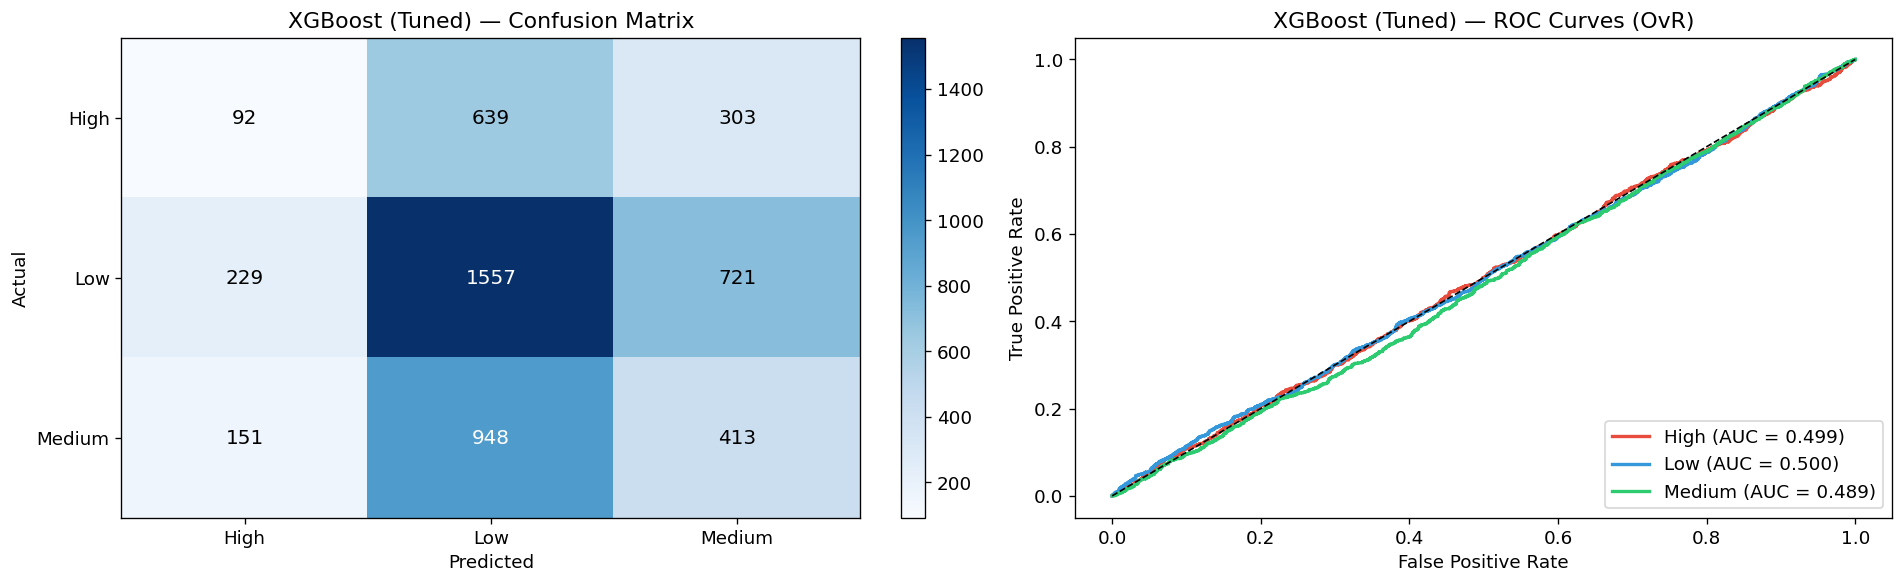

In [41]:
# ============================================================
# Evaluate Tuned XGBoost
# ============================================================

xgb_tuned = grid_search.best_estimator_

xgb_tuned_results = evaluate_model(xgb_tuned, X_test, y_test, "XGBoost (Tuned)", target_encoder)
results.append(xgb_tuned_results)

## Step 7 — Model Comparison & Feature Importance

Model Comparison — All Metrics on Test Set:
                     Accuracy  Macro F1  Weighted F1  ROC-AUC (OvR)
Model                                                              
Logistic Regression    0.3196    0.3081       0.3227         0.5063
XGBoost (Default)      0.4445    0.3083       0.3886         0.5114
Random Forest          0.4302    0.3205       0.3928         0.5086
XGBoost (Tuned)        0.4081    0.3178       0.3822         0.4958


Best model per metric:
  Accuracy             → XGBoost (Default) (0.4445)
  Macro F1             → Random Forest (0.3205)
  Weighted F1          → Random Forest (0.3928)
  ROC-AUC (OvR)        → XGBoost (Default) (0.5114)


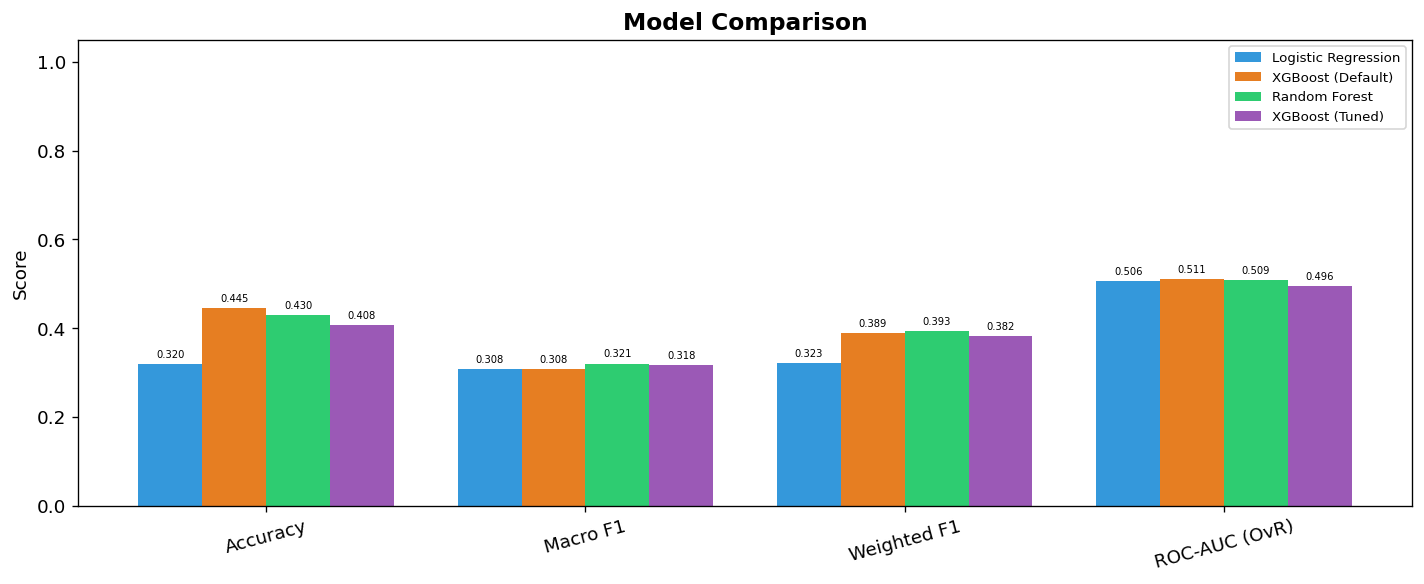

In [42]:
# ============================================================
# Model Comparison Summary
# ============================================================

results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")

print("Model Comparison — All Metrics on Test Set:")
print("=" * 70)
print(results_df.to_string())

# Highlight best model per metric
print("\n\nBest model per metric:")
for col in results_df.columns:
    best = results_df[col].idxmax()
    print(f"  {col:20s} → {best} ({results_df[col].max():.4f})")

# Visual comparison
n_models = len(results_df)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df.columns))
width = 0.8 / n_models
all_colors = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (model_name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, row.values, width, label=model_name, color=all_colors[i % len(all_colors)])

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(results_df.columns, rotation=15)
ax.set_ylabel("Score")
ax.set_title("Model Comparison", fontsize=14, fontweight="bold")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

for i, (model_name, row) in enumerate(results_df.iterrows()):
    for j, val in enumerate(row.values):
        ax.text(x[j] + i * width, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=6)

plt.tight_layout()
plt.show()

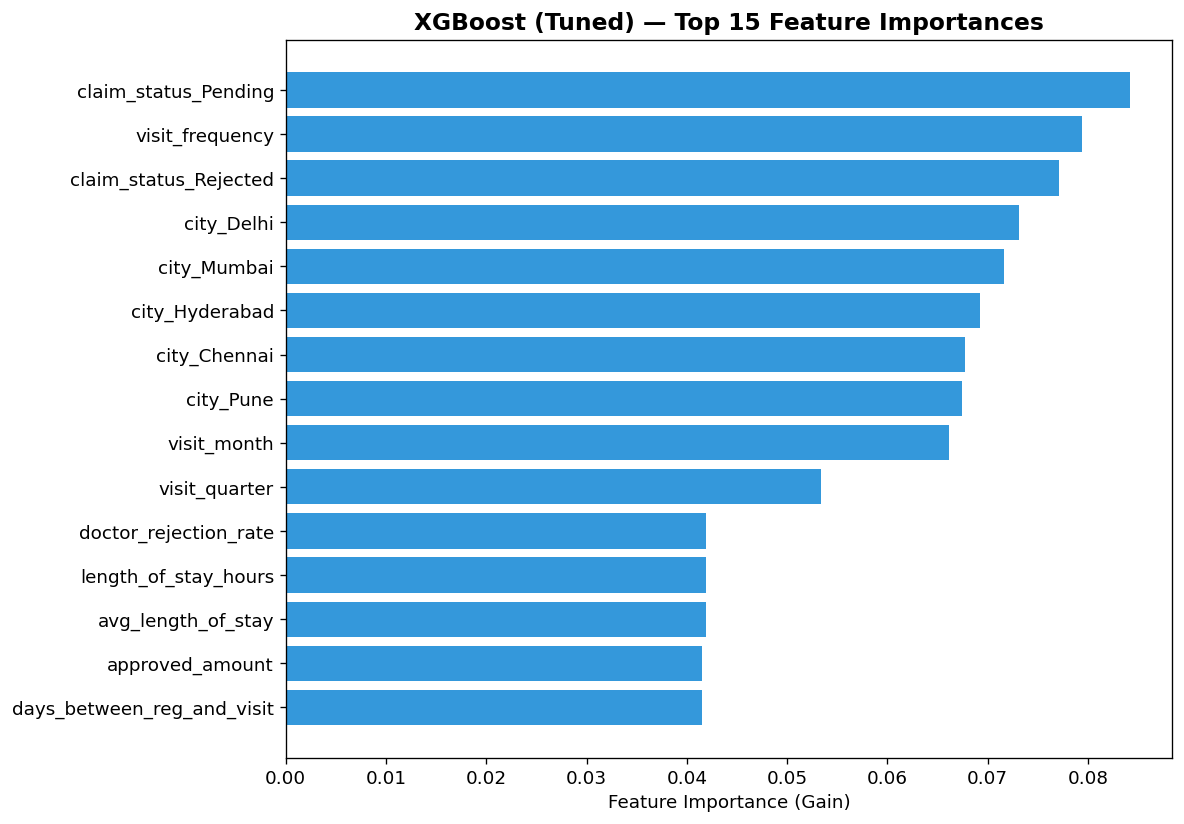


Top 15 features:
  claim_status_Pending                | 0.0842
  visit_frequency                     | 0.0794
  claim_status_Rejected               | 0.0771
  city_Delhi                          | 0.0732
  city_Mumbai                         | 0.0716
  city_Hyderabad                      | 0.0692
  city_Chennai                        | 0.0677
  city_Pune                           | 0.0674
  visit_month                         | 0.0661
  visit_quarter                       | 0.0534
  doctor_rejection_rate               | 0.0419
  length_of_stay_hours                | 0.0419
  avg_length_of_stay                  | 0.0419
  approved_amount                     | 0.0416
  days_between_reg_and_visit          | 0.0415


In [43]:
# ============================================================
# Feature Importance — Tuned XGBoost (Top 15)
# ============================================================

importances = xgb_tuned.feature_importances_
feature_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Show top 15
top_n = min(15, len(feature_imp))
top_features = feature_imp.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_features.index, top_features.values, color="#3498db")
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title(f"XGBoost (Tuned) — Top {top_n} Feature Importances", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features:")
for name, imp in top_features[::-1].items():
    print(f"  {name:35s} | {imp:.4f}")

In [44]:
# ============================================================
# Document All Hyperparameters
# ============================================================

print("=" * 60)
print("  Hyperparameter Documentation")
print("=" * 60)

print("\n1. Logistic Regression (Baseline):")
print(f"   random_state   = {RANDOM_STATE}")
print(f"   max_iter       = 1000")
print(f"   class_weight   = balanced")
print(f"   multi_class    = multinomial")
print(f"   solver         = lbfgs")

print("\n2. XGBoost (Default):")
print(f"   random_state   = {RANDOM_STATE}")
print(f"   n_estimators   = 100")
print(f"   max_depth      = 6")
print(f"   learning_rate  = 0.1")
print(f"   eval_metric    = mlogloss")

print("\n3. XGBoost (Tuned via GridSearchCV):")
print(f"   random_state   = {RANDOM_STATE}")
for k, v in grid_search.best_params_.items():
    print(f"   {k:17s} = {v}")
print(f"   Best CV F1     = {grid_search.best_score_:.4f}")

print("\n4. SMOTE:")
print(f"   random_state   = {RANDOM_STATE}")
print(f"   Applied to     = Training data only")

print("\n5. GridSearchCV:")
print(f"   cv             = 3")
print(f"   scoring        = f1_macro")
print(f"   refit          = True")
print(f"   Total combos   = {np.prod([len(v) for v in param_grid.values()])}")

print(f"\n{'='*60}")
print(f"  RANDOM_STATE = {RANDOM_STATE} used throughout for reproducibility")
print(f"{'='*60}")

  Hyperparameter Documentation

1. Logistic Regression (Baseline):
   random_state   = 42
   max_iter       = 1000
   class_weight   = balanced
   multi_class    = multinomial
   solver         = lbfgs

2. XGBoost (Default):
   random_state   = 42
   n_estimators   = 100
   max_depth      = 6
   learning_rate  = 0.1
   eval_metric    = mlogloss

3. XGBoost (Tuned via GridSearchCV):
   random_state   = 42
   colsample_bytree  = 1.0
   learning_rate     = 0.2
   max_depth         = 7
   n_estimators      = 300
   subsample         = 0.8
   Best CV F1     = 0.3020

4. SMOTE:
   random_state   = 42
   Applied to     = Training data only

5. GridSearchCV:
   cv             = 3
   scoring        = f1_macro
   refit          = True
   Total combos   = 108

  RANDOM_STATE = 42 used throughout for reproducibility


## Experiment — Demographic & Patient-Level Features Only

Testing a model with only 6 hand-picked features: `age`, `gender`, `city`, `chronic_flag`, `visit_frequency`, `avg_length_of_stay`. No billing or claim data — purely demographic and visit-pattern features.

Features: ['age', 'gender', 'city', 'chronic_flag', 'visit_frequency', 'avg_length_of_stay']
Encoded shape — Train: (29889, 10), Test: (5053, 10)
  LR (Demographic Only) — Evaluation Results

Accuracy:     0.3303
Macro F1:     0.3220
Weighted F1:  0.3408
ROC-AUC (OvR): 0.5093

Classification Report:
              precision    recall  f1-score   support

        High       0.21      0.42      0.28      1034
         Low       0.51      0.33      0.40      2507
      Medium       0.30      0.28      0.29      1512

    accuracy                           0.33      5053
   macro avg       0.34      0.34      0.32      5053
weighted avg       0.39      0.33      0.34      5053



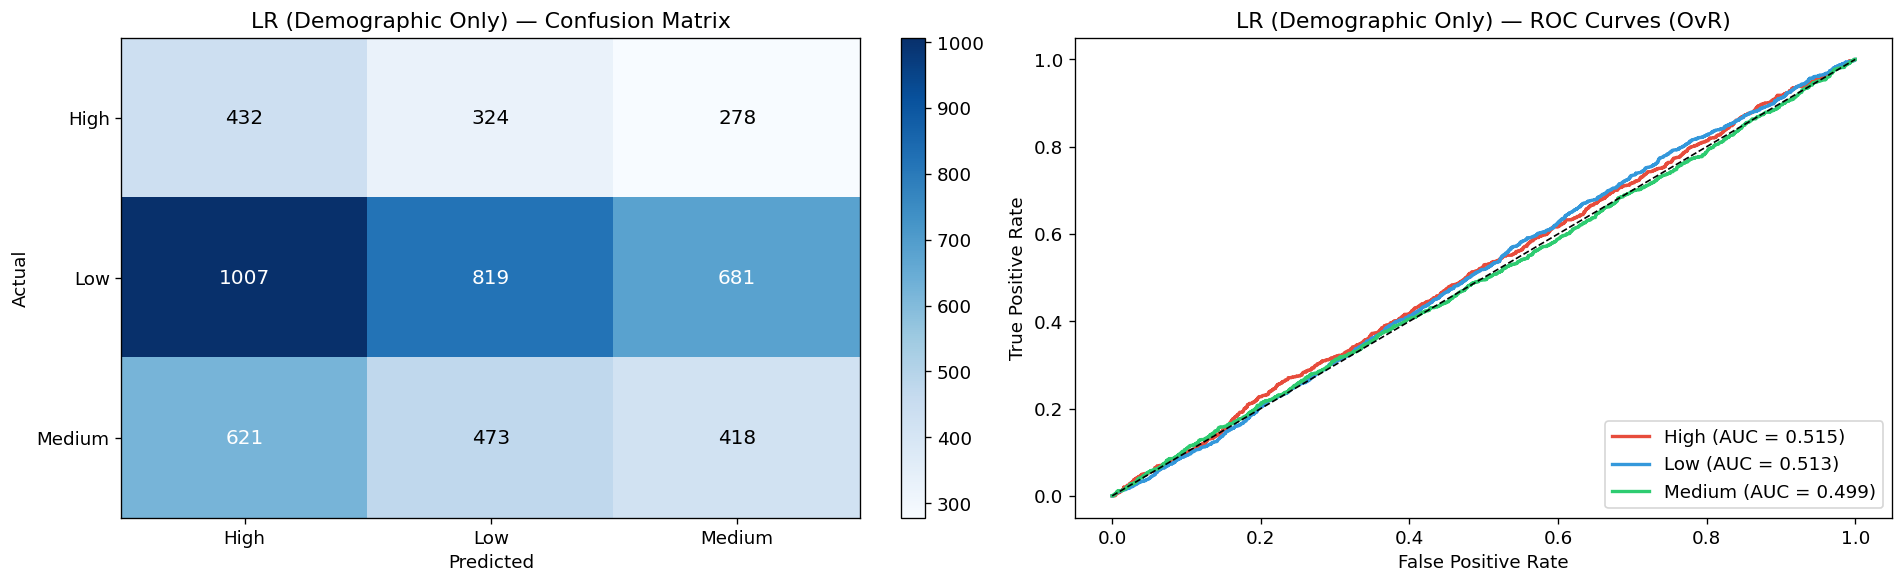

  XGB (Demographic Only) — Evaluation Results

Accuracy:     0.3956
Macro F1:     0.3173
Weighted F1:  0.3769
ROC-AUC (OvR): 0.4861

Classification Report:
              precision    recall  f1-score   support

        High       0.18      0.12      0.14      1034
         Low       0.49      0.59      0.54      2507
      Medium       0.29      0.26      0.27      1512

    accuracy                           0.40      5053
   macro avg       0.32      0.32      0.32      5053
weighted avg       0.37      0.40      0.38      5053



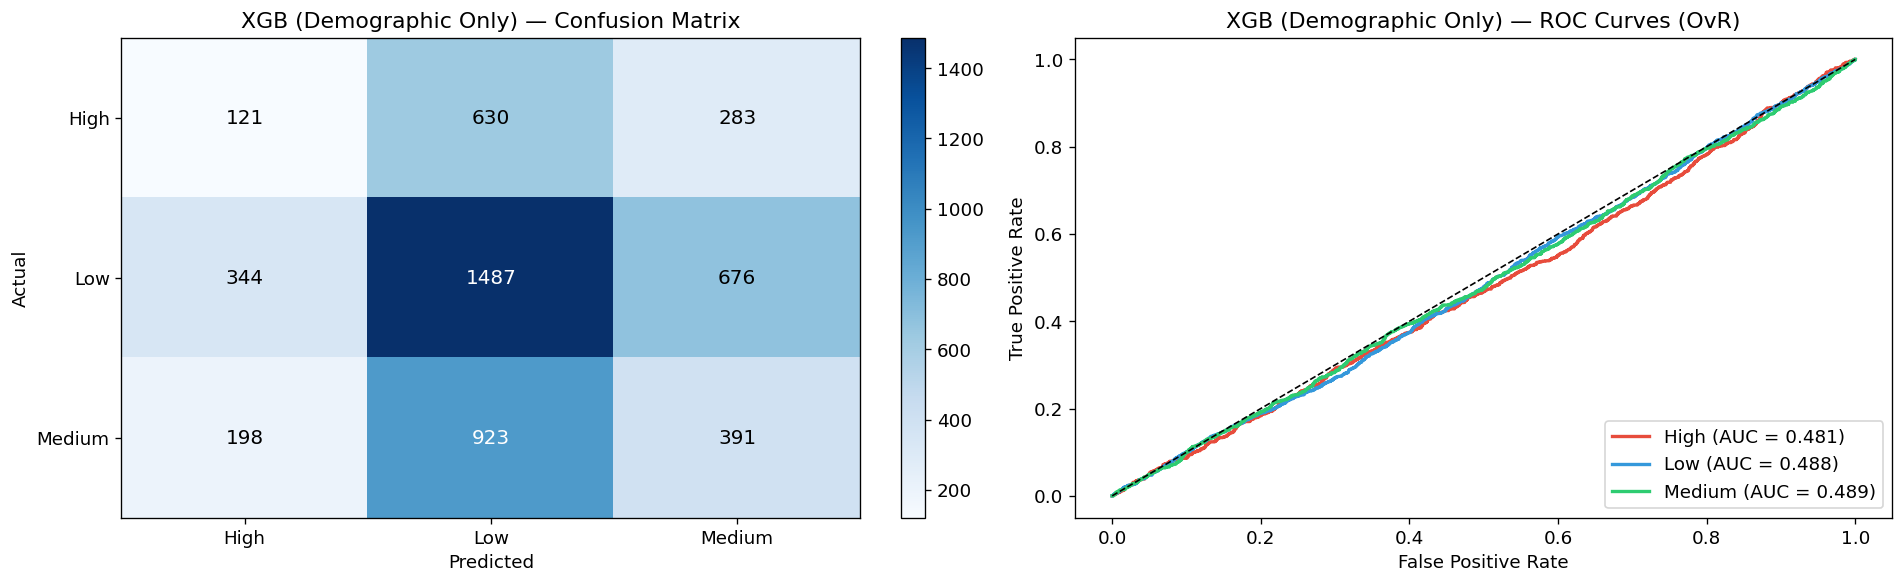


  Comparison: Demographic-Only vs Full Feature Set
                        Accuracy  Macro F1  Weighted F1  ROC-AUC (OvR)
Model                                                                 
LR (Demographic Only)     0.3303    0.3220       0.3408         0.5093
XGB (Demographic Only)    0.3956    0.3173       0.3769         0.4861
Logistic Regression       0.3196    0.3081       0.3227         0.5063
XGBoost (Default)         0.4445    0.3083       0.3886         0.5114
Random Forest             0.4302    0.3205       0.3928         0.5086
XGBoost (Tuned)           0.4081    0.3178       0.3822         0.4958


In [45]:
# ============================================================
# Experiment: Model with demographic + patient-level features only
# ============================================================

exp_features = ["age", "gender", "city", "chronic_flag", "visit_frequency", "avg_length_of_stay"]
exp_cat = ["gender", "city"]
exp_num = ["age", "chronic_flag", "visit_frequency", "avg_length_of_stay"]

# Reuse the same time-based split (train_df / test_df already exist)
exp_train = train_df[exp_features].copy()
exp_test = test_df[exp_features].copy()

# One-Hot encode categoricals
exp_train_enc = pd.get_dummies(exp_train, columns=exp_cat, drop_first=True)
exp_test_enc = pd.get_dummies(exp_test, columns=exp_cat, drop_first=True)
exp_test_enc = exp_test_enc.reindex(columns=exp_train_enc.columns, fill_value=0)

# Scale numeric features
exp_scaler = StandardScaler()
exp_scaler.fit(exp_train_enc[exp_num])
exp_train_enc[exp_num] = exp_scaler.transform(exp_train_enc[exp_num])
exp_test_enc[exp_num] = exp_scaler.transform(exp_test_enc[exp_num])

# SMOTE on training data
exp_smote = SMOTE(random_state=RANDOM_STATE)
X_train_exp, y_train_exp = exp_smote.fit_resample(exp_train_enc.values, y_train)
X_test_exp = exp_test_enc.values

print(f"Features: {exp_features}")
print(f"Encoded shape — Train: {X_train_exp.shape}, Test: {X_test_exp.shape}")

# --- Logistic Regression ---
lr_exp = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced", solver="lbfgs")
lr_exp.fit(X_train_exp, y_train_exp)
lr_exp_results = evaluate_model(lr_exp, X_test_exp, y_test, "LR (Demographic Only)", target_encoder)

# --- XGBoost ---
xgb_exp = XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", use_label_encoder=False, n_jobs=-1)
xgb_exp.fit(X_train_exp, y_train_exp)
xgb_exp_results = evaluate_model(xgb_exp, X_test_exp, y_test, "XGB (Demographic Only)", target_encoder)

# --- Compare with main models ---
print("\n" + "=" * 70)
print("  Comparison: Demographic-Only vs Full Feature Set")
print("=" * 70)
compare = pd.DataFrame([lr_exp_results, xgb_exp_results] + results)
compare = compare.set_index("Model")
print(compare.to_string())

## Experiment — Without SMOTE

Retrain all models on the original (imbalanced) training data to see if SMOTE is helping or hurting performance.

  LR (No SMOTE) — Evaluation Results

Accuracy:     0.3198
Macro F1:     0.3130
Weighted F1:  0.3258
ROC-AUC (OvR): 0.5078

Classification Report:
              precision    recall  f1-score   support

        High       0.20      0.32      0.25      1034
         Low       0.50      0.26      0.35      2507
      Medium       0.30      0.41      0.35      1512

    accuracy                           0.32      5053
   macro avg       0.33      0.33      0.31      5053
weighted avg       0.38      0.32      0.33      5053



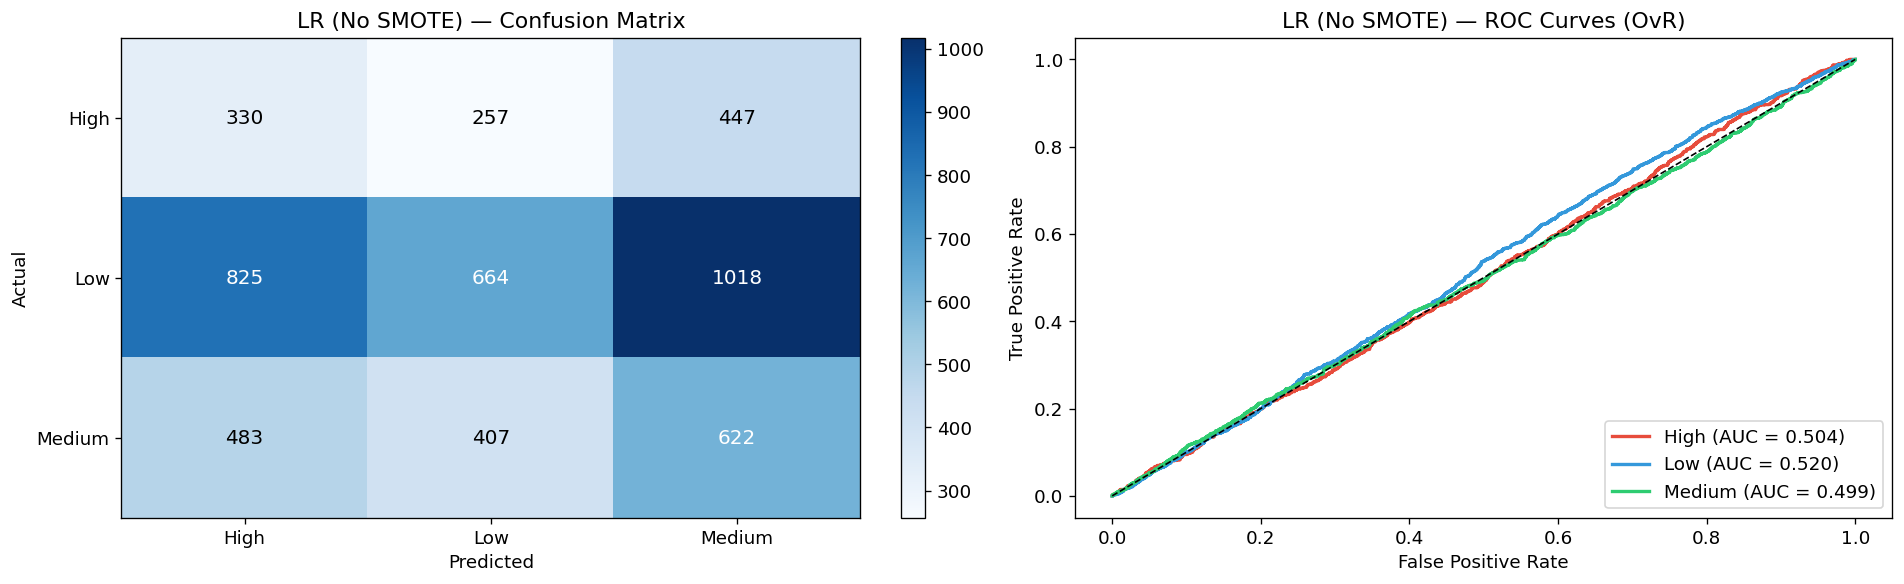

  XGB (No SMOTE) — Evaluation Results

Accuracy:     0.4672
Macro F1:     0.2907
Weighted F1:  0.3819
ROC-AUC (OvR): 0.5167

Classification Report:
              precision    recall  f1-score   support

        High       0.18      0.02      0.03      1034
         Low       0.50      0.84      0.63      2507
      Medium       0.31      0.16      0.22      1512

    accuracy                           0.47      5053
   macro avg       0.33      0.34      0.29      5053
weighted avg       0.38      0.47      0.38      5053



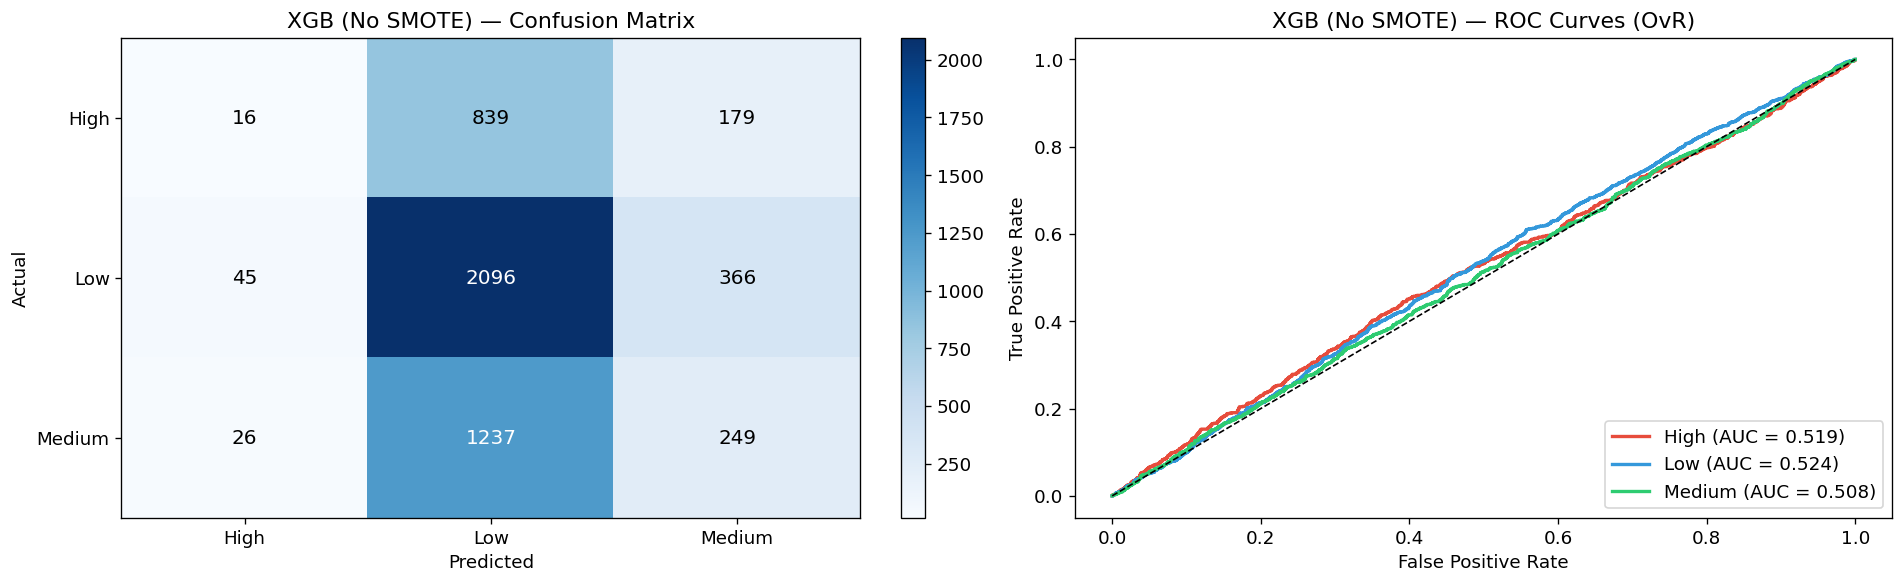

  RF (No SMOTE) — Evaluation Results

Accuracy:     0.4805
Macro F1:     0.2805
Weighted F1:  0.3761
ROC-AUC (OvR): 0.5092

Classification Report:
              precision    recall  f1-score   support

        High       0.21      0.01      0.02      1034
         Low       0.50      0.89      0.64      2507
      Medium       0.33      0.12      0.18      1512

    accuracy                           0.48      5053
   macro avg       0.35      0.34      0.28      5053
weighted avg       0.39      0.48      0.38      5053



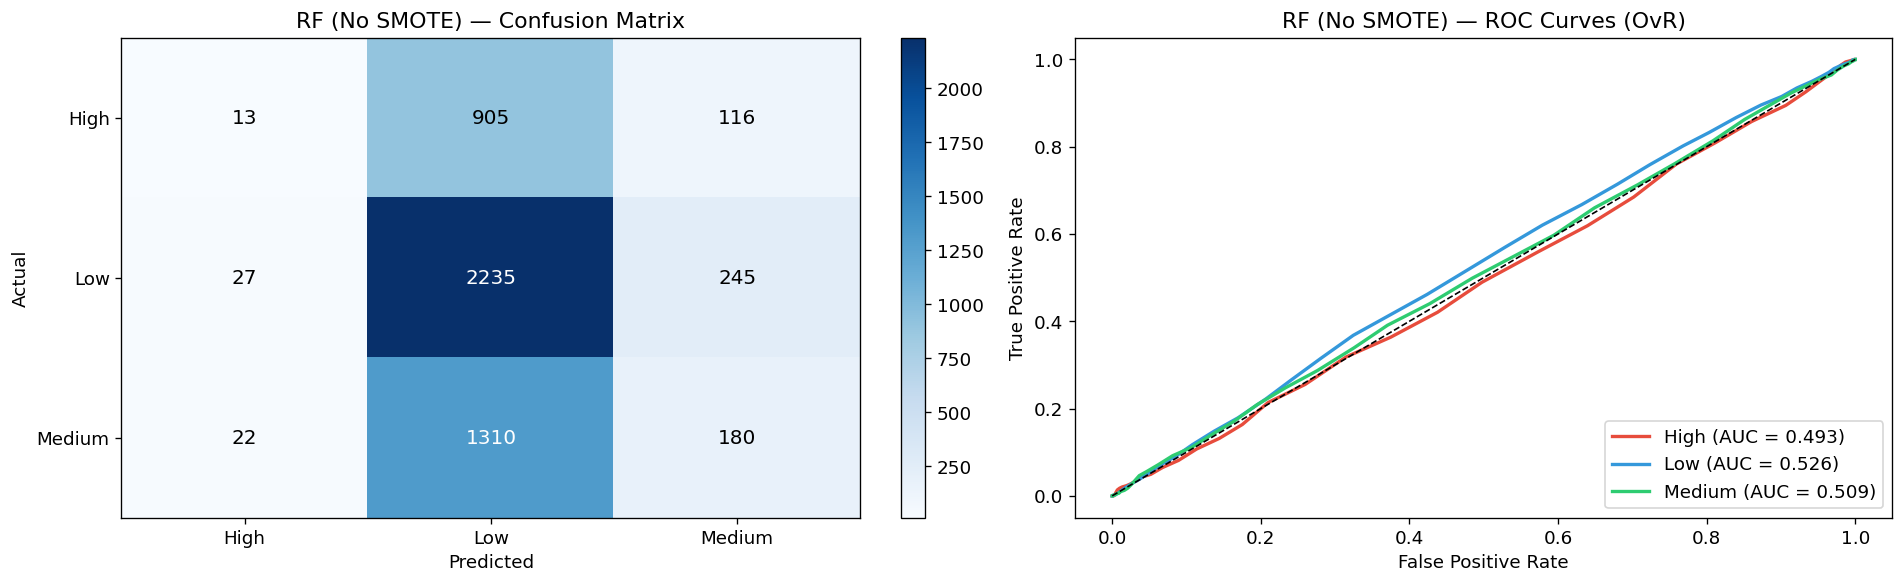


  SMOTE vs No SMOTE — Head-to-Head Comparison
                     Accuracy  Macro F1  Weighted F1  ROC-AUC (OvR)
Model                                                              
Logistic Regression    0.3196    0.3081       0.3227         0.5063
XGBoost (Default)      0.4445    0.3083       0.3886         0.5114
Random Forest          0.4302    0.3205       0.3928         0.5086
XGBoost (Tuned)        0.4081    0.3178       0.3822         0.4958
LR (No SMOTE)          0.3198    0.3130       0.3258         0.5078
XGB (No SMOTE)         0.4672    0.2907       0.3819         0.5167
RF (No SMOTE)          0.4805    0.2805       0.3761         0.5092


Best model overall per metric:
  Accuracy             → RF (No SMOTE) (0.4805)
  Macro F1             → Random Forest (0.3205)
  Weighted F1          → Random Forest (0.3928)
  ROC-AUC (OvR)        → XGB (No SMOTE) (0.5167)


In [46]:
# ============================================================
# Retrain all models WITHOUT SMOTE
# ============================================================

no_smote_results = []

# 1. Logistic Regression (no SMOTE)
lr_ns = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced", solver="lbfgs")
lr_ns.fit(X_train, y_train)
no_smote_results.append(evaluate_model(lr_ns, X_test, y_test, "LR (No SMOTE)", target_encoder))

# 2. XGBoost (no SMOTE)
xgb_ns = XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", use_label_encoder=False, n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1)
xgb_ns.fit(X_train, y_train)
no_smote_results.append(evaluate_model(xgb_ns, X_test, y_test, "XGB (No SMOTE)", target_encoder))

# 3. Random Forest (no SMOTE)
rf_ns = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, class_weight="balanced", n_jobs=-1)
rf_ns.fit(X_train, y_train)
no_smote_results.append(evaluate_model(rf_ns, X_test, y_test, "RF (No SMOTE)", target_encoder))

# --- Side-by-side comparison ---
print("\n" + "=" * 80)
print("  SMOTE vs No SMOTE — Head-to-Head Comparison")
print("=" * 80)

smote_df = pd.DataFrame(results).set_index("Model")
no_smote_df = pd.DataFrame(no_smote_results).set_index("Model")
combined = pd.concat([smote_df, no_smote_df])

print(combined.to_string())

print("\n\nBest model overall per metric:")
for col in combined.columns:
    best = combined[col].idxmax()
    print(f"  {col:20s} → {best} ({combined[col].max():.4f})")